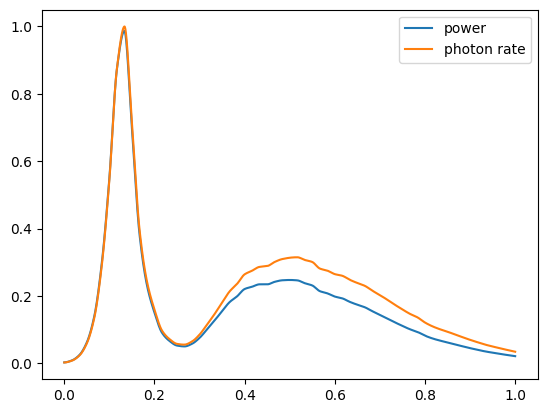

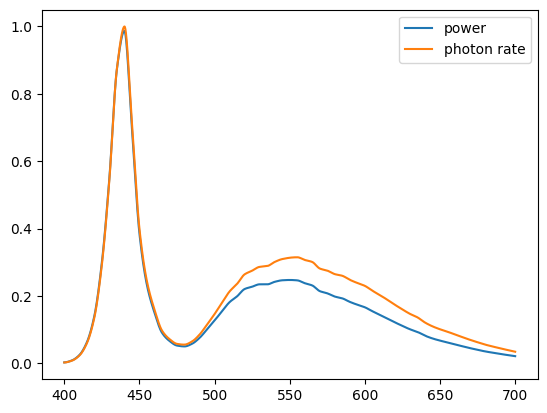

In [18]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from pathlib import Path
import matplotlib.pyplot as plt

csv_path = Path("../configs/mcwhl5_spectrum_digitized_from_plot_5nm.csv")
spec = pd.read_csv(csv_path)

lam_data = spec["wavelength_nm"].to_numpy()
S_data = spec["normalized_intensity"].to_numpy()

lam_normalized = (lam_data - lam_data.min())/(lam_data.max() - lam_data.min())

S = PchipInterpolator(lam_normalized, S_data, extrapolate=False)

lam = np.linspace(400, 700, 2000)
lam_1 = np.linspace(0, 1, 2000)
S_lam = S(lam_1)




plt.plot(lam_1,S_lam, label="power")


def S_photon_rate(lam_norm):
    lam = lam_norm*300 + 400
    return lam*S(lam_norm)

rate = S_photon_rate(lam_1)
rate = rate/rate.max()
plt.plot(lam_1, rate, label="photon rate")
plt.legend()
plt.show()

# plt.plot(lam, rate/S_lam)
# plt.show()



plt.plot(lam,S_lam, label="power")
plt.plot(lam, rate, label="photon rate")
plt.legend()
plt.show()